# Vertical integration

Vertical integration combines modalities measured in the same cells. Examples are RNA and surface protein from CITE-seq, or RNA and ATAC from 10x Multiome. This tutorial runs Matilda and sciPENN on `D11`, a CITE-seq dataset of 2,864 cells, and then on data in your own format.

Methods run on Linux. On macOS or Windows, [open this notebook in Colab](https://colab.research.google.com/github/DSichang/scMultiBench/blob/main/notebooks/tutorial_vertical.ipynb).

## 1. Install

This cell installs `multibench-sc`. It keeps the numpy and pandas that are already installed, so Colab needs no restart.

<details>
<summary>Details</summary>

On Colab, choose a GPU runtime before you run the notebook: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, an environment that has a smaller CPU build gets that build, and training methods run slower.

</details>

In [1]:
import numpy, pandas
%pip install -q multibench-sc numpy=={numpy.__version__} pandas=={pandas.__version__}

Note: you may need to restart the kernel to use updated packages.


## 2. Download the data and the environments

`mtb.data.fetch` downloads `D11` (11 MB) once. Each method runs in its own environment. `mtb.env.install` downloads the environments for Matilda and sciPENN, with no conda needed. The download is 1.1 GB on a computer without a GPU and 5.1 GB on one with a GPU.

<details>
<summary>Details</summary>

`state` is `PACKED` for an environment downloaded now and `have` for one that was already there. Without `dry_run=False`, `mtb.env.install` downloads nothing and returns the plan with its sizes.

Environments go to `mtb.config.DEFAULT.envs_dir`. To use another disk, set it before this cell.

From a terminal, `multibench env install --methods Matilda,sciPENN --packed --run` does the same. With `--category vertical` instead of `--methods`, it installs every vertical environment: 18 envs, 48.1 GB to download on a CPU host, 56.4 GB on a GPU host.

</details>

In [2]:
import pandas as pd
import multibench as mtb

mtb.data.fetch("D11")

downloading D11 (11 MB) from https://github.com/DSichang/scMultiBench/releases/download/data-v1/D11.tar.gz ...


PosixPath('/tmp/mbtut3/home/.cache/multibench/data')

In [3]:
METHODS = ["Matilda", "sciPENN"]
envs = mtb.env.install(METHODS, dry_run=False)
pd.DataFrame(envs)[["env", "methods", "state"]]

[env] downloading env_sciPENN (gpu build) 2.1 GB ...


[env]   0.2 GB of 2.1 GB (18 MB/s)


[env]   0.4 GB of 2.1 GB (18 MB/s)


[env]   0.6 GB of 2.1 GB (18 MB/s)


[env]   0.8 GB of 2.1 GB (18 MB/s)


...

[env]   2.4 GB of 3.0 GB (47 MB/s)


[env]   2.7 GB of 3.0 GB (49 MB/s)


[env]   3.0 GB of 3.0 GB (51 MB/s)


[env] unpacking matilda -> /tmp/mbtut3/home/.cache/multibench/envs/matilda ...


,env,methods,state
0,env_sciPENN,[sciPENN],PACKED
1,matilda,[Matilda],PACKED


## 3. Run the methods

`run_all` runs each method on `D11` and scores its output with the scIB metrics. `res.summary` has one row per method with its status, run time and scores. Higher is better for every metric.

<details>
<summary>Details</summary>

Each method writes an embedding: a table of numbers with one row per cell. `run_all` scores it against the cell-type labels of `D11`.

The clustering metrics `ARI`, `NMI`, `ASW`, `iASW`, `iF1` and `cLISI` measure how well the embedding separates the cell types. The batch metrics `ASW_batch`, `GC` and `iLISI` measure how well the batches mix. They appear only when the data has several batches.

`res.failures` says why a method failed. `params={"Method": {"key": value}}` sets a method's parameters, and `mtb.params_for` lists them. Many methods take none.

`mtb.load_batch("out/D11")` reloads these results later without running anything.

</details>

In [4]:
res = mtb.run_all("D11", "vertical", methods=METHODS, out_dir="out/D11")
res.summary

[run_all] 1 more row needs files this folder does not have. mtb.scan shows it.


[run_all] Matilda (vertical/D11) ...


Fetching the method scripts from PYangLab/scMultiBench into /tmp/mbtut3/home/.cache/multibench/scMultiBench_ref ...


multibench: rebuilt scib's LISI helper knn_graph.o from source with /usr/bin/g++ (the shipped binary could not run here)


[run_all]   -> CHAIN_OK (46.3s) ARI 0.929


[run_all] sciPENN (vertical/D11) ...


[run_all]   -> CHAIN_OK (27.9s) ARI 0.641


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,label_order_note,caveat,reason
0,Matilda,CHAIN_OK,46.3,embedding,"[2864, 100]",10,cty.csv,NaN,None,1,0.9290,0.9258,0.6793,0.6822,0.9568,0.9989,single ordering,,
1,sciPENN,CHAIN_OK,27.9,embedding,"[2864, 512]",1,cty.csv,NaN,None,1,0.6413,0.7132,0.6347,0.6261,0.6607,0.9796,single ordering,,


## 4. Plot

`res.plot()` draws the scores as a bubble table. Circle size shows the rank within a column, and bigger is better. The fill compares a value with the other rows in the same column.

<details>
<summary>Details</summary>

The lightest fill is the lowest value in this figure, not zero.

Metrics are grouped by family: blue for dimension reduction and clustering, green for batch correction. Each family starts with an `Overall` bar. Its length and colour both show the family score.

A column whose rows all hold the same value is drawn grey, and the note under the figure names it.

</details>

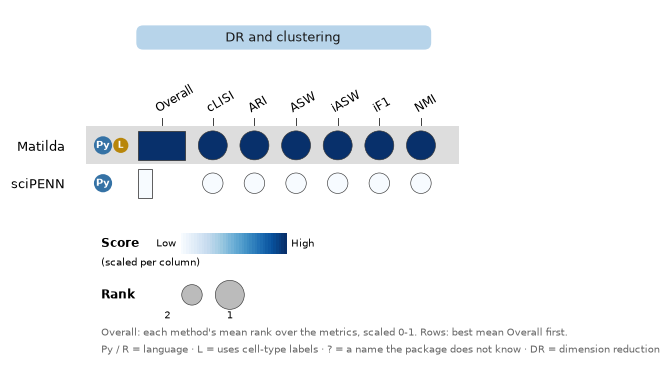

In [5]:
res.plot()

## 5. Your own data

Your data needs raw counts for every modality and a cell type for each cell. `mtb.io.export_dataset` writes an AnnData as a dataset folder, and `run_all` runs on that folder. For RNA + ATAC, each method reads either peaks or gene activity: `mtb.method_info(m)["atac"]` says which.

<details>
<summary>Details: export</summary>

A 10x Multiome MuData goes in with one call. Here the labels are in `mdata.obs`. For labels in `mdata["rna"].obs`, write `labels="rna:celltype"`.

```python
mtb.io.export_dataset(mdata, "mydata/MYMULTIOME", rna="rna", atac="atac",
                      atac_kind="peak", labels="obs:celltype",
                      category="vertical")
```

A cellranger-arc AnnData read with `gex_only=False` holds genes and peaks in one `X`. A feature filter splits them: `rna="X[feature_types=Gene Expression]"` and `atac="X[feature_types=Peaks]"`.

Keep several samples in one folder, without `batch=`. To score the batch mixing, pass the batch column to `run_all(batch=...)`.

The folder name, `MYCITE`, is the dataset name for `run_all`, and `data_path` is the folder that holds it.

`mtb.scan("MYCITE", "vertical", data_path="mydata")` checks the folder and the environments without running anything. Its `reason` column says what is missing.

`overwrite=True` replaces the files of an earlier run of this cell. Without it, `export_dataset` raises `FileExistsError` rather than replace a file.

</details>

Here an AnnData made from 60% of `D11`'s cells takes the place of your data:

In [6]:
import scanpy as sc

d = mtb.config.DEFAULT.data_path / "D11"
adata = mtb.io.read_canonical(d / "rna.h5")
adata.obsm["protein"] = mtb.io.read_canonical(d / "adt.h5").to_df()
adata.obs["celltype"] = pd.read_csv(d / "cty.csv")["x"].values
adata = sc.pp.subsample(adata, fraction=0.6, random_state=0, copy=True)
adata

AnnData object with n_obs × n_vars = 1718 × 9822
    obs: 'celltype'
    obsm: 'protein'

Write the folder, then run the same methods on it:

In [7]:
mtb.io.export_dataset(adata, "mydata/MYCITE", rna="X", adt="obsm:protein",
                      labels="obs:celltype", overwrite=True)

mine = mtb.run_all("MYCITE", "vertical", methods=METHODS, data_path="mydata",
                   out_dir="out/MYCITE")
mine.summary

[run_all] 1 more row needs files this folder does not have. mtb.scan shows it.


[run_all] Matilda (vertical/MYCITE) ...


[run_all]   -> CHAIN_OK (29.8s) ARI 0.948


[run_all] sciPENN (vertical/MYCITE) ...


[run_all]   -> CHAIN_OK (21.8s) ARI 0.514


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,label_order_note,caveat,reason
0,Matilda,CHAIN_OK,29.8,embedding,"[1718, 100]",10,cty.csv,NaN,None,1,0.9475,0.9481,0.6726,0.6910,0.9809,0.9993,single ordering,,
1,sciPENN,CHAIN_OK,21.8,embedding,"[1718, 512]",1,cty.csv,NaN,None,1,0.5144,0.6620,0.6146,0.6195,0.6430,0.9645,single ordering,,


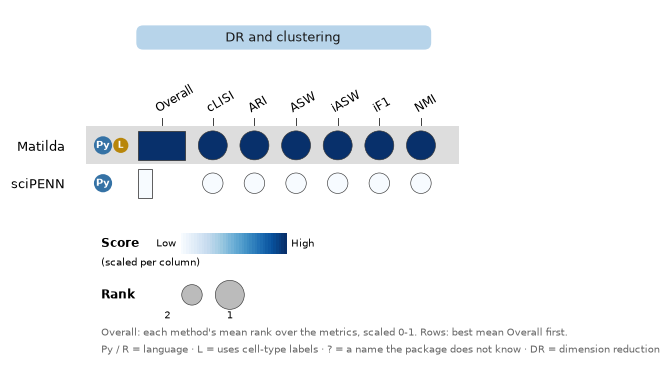

In [8]:
mine.plot()

## 6. Stored scores

The package ships stored scores for 13 methods on `D11`. `load_results` reads them and `mtb.plot.bubble` draws them, without running anything.

<details>
<summary>Details</summary>

`source="rerun"` reads the package's own runs of the methods. `source="published"`, the default, reads the published scIB tables, which hold 6 methods for `D11`.

The stored scores used the `leidenalg` backend for Leiden clustering, and `run_all` uses `igraph` by default. The two backends can move ARI by up to about 0.1. To compare your runs with these scores, set `mtb.config.DEFAULT.leiden_flavor = "leidenalg"` before `run_all`.

</details>

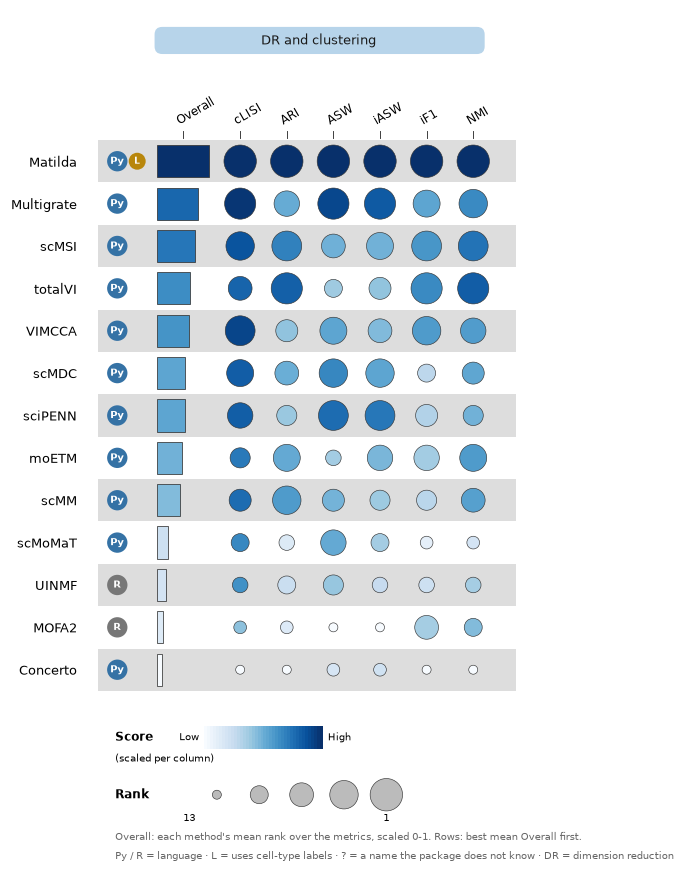

In [9]:
long = mtb.load_results("vertical", dataset="D11", source="rerun")
mtb.plot.bubble(long)

## Troubleshooting

`res.failures` lists each method that failed or was skipped. Its `error` column ends with the method's error output.

<details>
<summary>Details</summary>

| symptom | fix |
|---|---|
| `env.install` refuses on macOS or Windows | methods run only on Linux: use Colab or a Linux machine |
| a method needs an NVIDIA GPU | choose a GPU runtime on Colab, or a machine with a GPU |
| a warning that values are not whole numbers | export raw counts, for example with `rna="layer:counts"` |
| `... matrix/data as cells x features` | the matrix is transposed: export it again with `mtb.io.export_dataset` |
| a method times out | raise `timeout=` in `run_all` |
| low `label_order_confidence` | several label files fit the cell count: check `label_order_candidates` in `res.results` |
| batch metrics use the wrong batches | `res.rescore(batch=my_vector)` scores again without running the methods |

</details>

## Next steps

- `mtb.cite(METHODS)` returns the citations for the benchmark and the methods you ran.
- The other tutorials: [diagonal](https://dsichang.github.io/scMultiBench/tutorials/diagonal/), [mosaic](https://dsichang.github.io/scMultiBench/tutorials/mosaic/), [cross](https://dsichang.github.io/scMultiBench/tutorials/cross/).
- The guides: [run](https://dsichang.github.io/scMultiBench/tutorials/run/), [evaluate](https://dsichang.github.io/scMultiBench/tutorials/evaluate/), [plot](https://dsichang.github.io/scMultiBench/tutorials/plot/) and [discover methods](https://dsichang.github.io/scMultiBench/tutorials/discover/).
- The [interactive explorer](https://shiny.maths.usyd.edu.au/scMultiBench/) has the full benchmark's rankings, with no install needed.